# **Week 3: Advanced Data Analysis and Visualization in Logistics**

## **Project Title**

**Logistics Delivery Performance Analysis and Strategic Planning Using Python**

## **Objective**

This notebook focuses on advanced exploratory data analysis and visualization of a hypothetical logistics dataset. The objective is to analyze important logistics variables such as delivery time, shipment volume, transportation cost, distance, transportation mode, and on-time delivery performance. Python is used to generate the simulated dataset, perform exploratory data analysis, calculate descriptive statistics and correlations, create meaningful visualizations, and identify operational trends, cost drivers, and potential logistics bottlenecks.

The analysis demonstrates how data visualization and analytical techniques can support data-driven decision-making in logistics operations.

# **Notebook Contents**

1. **Objective**
2. **Data Simulation and Dataset Description**
3. **Python Environment Setup**
4. **Hypothetical Dataset Generation**
5. **Initial Data Inspection**
6. **Exploratory Data Analysis**
   - Descriptive Statistics
   - Central Tendency
   - Distribution Analysis
   - Correlation Analysis
7. **Logistics Performance Analysis**
   - Delivery Time Analysis
   - Shipment Volume Analysis
   - Transportation Cost Analysis
   - On-Time Delivery Analysis
8. **Data Visualization**
   - Delivery Time Distribution
   - Shipment Volume by Region
   - Delivery Time by Transportation Mode
   - Distance vs Transportation Cost
   - Shipment Volume vs Transportation Cost
   - Monthly Shipment Trend
   - Correlation Heatmap
9. **Analytical Insights**
10. **Logistics Bottlenecks and Cost Drivers**
11. **Business Recommendations**
12. **Key Findings Summary**
13. **Conclusion**

# **1. Objective**

The objective of this task is to perform advanced exploratory data analysis and visualization using a hypothetical logistics dataset. The analysis focuses on identifying patterns in delivery performance, shipment volume, transportation costs, distance, transportation modes, and on-time delivery performance.

The results will be used to identify operational trends, potential bottlenecks, and cost drivers and to develop data-driven recommendations for improving logistics efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Python environment is ready...")

Pandas version: 2.2.3
NumPy version: 2.1.3
Python environment is ready...


# **2. Data Simulation and Dataset Description**

## **2.1 Dataset Structure**

A hypothetical logistics dataset is created using Python to simulate shipment-level logistics operations. The dataset is designed to represent realistic logistics activities involving different regions, transportation modes, shipment volumes, delivery durations, transportation costs, and distances.

The simulated dataset contains 500 shipment records.

## **2.2 Logistics Variables**

The dataset contains the following variables:

| Variable | Description |
|---|---|
| shipment_id | Unique identifier for each shipment |
| region | Geographic region of the shipment |
| transport_mode | Mode of transportation used |
| shipment_volume | Volume of goods transported |
| delivery_time_days | Number of days required for delivery |
| transportation_cost | Cost associated with transportation |
| distance_km | Transportation distance in kilometers |
| on_time | Indicates whether the shipment was delivered on time |

## **2.3 Business Context**

The hypothetical dataset represents a logistics company that wants to understand delivery efficiency, shipment patterns, transportation costs, and potential operational bottlenecks.

The simulated data allows different logistics relationships to be explored using exploratory data analysis and visualization techniques.

In [2]:
np.random.seed(42)

n = 500

logistics_data = pd.DataFrame({
    "shipment_id": [f"SHP{i:04d}" for i in range(1, n + 1)],
    "region": np.random.choice(
        ["North", "South", "East", "West"],
        size=n
    ),
    "transport_mode": np.random.choice(
        ["Road", "Rail", "Air", "Sea"],
        size=n,
        p=[0.45, 0.25, 0.15, 0.15]
    ),
    "shipment_volume": np.random.randint(
        10, 501, size=n
    ),
    "distance_km": np.random.randint(
        50, 2001, size=n
    )
})

# Generate delivery time based partly on distance
logistics_data["delivery_time_days"] = (
    2
    + logistics_data["distance_km"] / 400
    + np.random.normal(0, 1.5, n)
).round(1)

# Prevent unrealistic negative delivery times
logistics_data["delivery_time_days"] = (
    logistics_data["delivery_time_days"].clip(lower=1)
)

# Generate transportation cost based on distance and shipment volume
logistics_data["transportation_cost"] = (
    500
    + logistics_data["distance_km"] * 2
    + logistics_data["shipment_volume"] * 8
    + np.random.normal(0, 1000, n)
).round(2)

# Prevent negative costs
logistics_data["transportation_cost"] = (
    logistics_data["transportation_cost"].clip(lower=500)
)

# Generate on-time delivery status
logistics_data["on_time"] = (
    logistics_data["delivery_time_days"]
    <= 7
)

print("Hypothetical logistics dataset created successfully!")
print("Rows:", logistics_data.shape[0])
print("Columns:", logistics_data.shape[1])

logistics_data.head()

Hypothetical logistics dataset created successfully!
Rows: 500
Columns: 8


,shipment_id,region,transport_mode,shipment_volume,distance_km,delivery_time_days,transportation_cost,on_time
0,SHP0001,East,Road,444,96,2.2,4468.68,True
1,SHP0002,West,Road,207,1361,3.7,5810.59,True
2,SHP0003,North,Sea,143,827,6.3,1879.63,True
3,SHP0004,East,Road,76,1089,6.0,1525.19,True
4,SHP0005,East,Road,400,760,3.6,3694.34,True


# **3. Initial Data Inspection**

The simulated dataset is inspected before performing detailed analysis. This step helps verify the dataset structure, number of observations, column names, data types, and sample records.

In [3]:
print("Dataset Shape:", logistics_data.shape)

print("\nColumn Names:")
print(logistics_data.columns.tolist())

print("\nFirst 5 Records:")
display(logistics_data.head())

print("\nDataset Information:")
logistics_data.info()

Dataset Shape: (500, 8)

Column Names:
['shipment_id', 'region', 'transport_mode', 'shipment_volume', 'distance_km', 'delivery_time_days', 'transportation_cost', 'on_time']

First 5 Records:


,shipment_id,region,transport_mode,shipment_volume,distance_km,delivery_time_days,transportation_cost,on_time
0,SHP0001,East,Road,444,96,2.2,4468.68,True
1,SHP0002,West,Road,207,1361,3.7,5810.59,True
2,SHP0003,North,Sea,143,827,6.3,1879.63,True
3,SHP0004,East,Road,76,1089,6.0,1525.19,True
4,SHP0005,East,Road,400,760,3.6,3694.34,True



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   shipment_id          500 non-null    object 
 1   region               500 non-null    object 
 2   transport_mode       500 non-null    object 
 3   shipment_volume      500 non-null    int64  
 4   distance_km          500 non-null    int64  
 5   delivery_time_days   500 non-null    float64
 6   transportation_cost  500 non-null    float64
 7   on_time              500 non-null    bool   
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 28.0+ KB


# **4. Data Quality Check**

Before performing exploratory data analysis, the simulated logistics dataset is checked for missing values, duplicate records, and basic data consistency. These checks help ensure that the dataset is suitable for further analysis and visualization.

In [4]:
print("Missing values in each column:")
print(logistics_data.isnull().sum())

print("\nDuplicate records:")
print(logistics_data.duplicated().sum())

print("\nData types:")
print(logistics_data.dtypes)

Missing values in each column:
shipment_id            0
region                 0
transport_mode         0
shipment_volume        0
distance_km            0
delivery_time_days     0
transportation_cost    0
on_time                0
dtype: int64

Duplicate records:
0

Data types:
shipment_id             object
region                  object
transport_mode          object
shipment_volume          int64
distance_km              int64
delivery_time_days     float64
transportation_cost    float64
on_time                   bool
dtype: object


# **5. Exploratory Data Analysis**

## **5.1 Descriptive Statistics**

Descriptive statistics provide a summary of the numerical variables in the logistics dataset. Measures such as count, mean, standard deviation, minimum, maximum, and quartiles help understand the overall characteristics and variation in logistics operations.

In [5]:
numerical_columns = [
    "shipment_volume",
    "delivery_time_days",
    "transportation_cost",
    "distance_km"
]

display(logistics_data[numerical_columns].describe())

,shipment_volume,delivery_time_days,transportation_cost,distance_km
count,500.000000,500.000000,500.000000,500.00000
mean,254.090000,4.716000,4621.878880,1023.30600
std,141.842887,1.916583,1875.768708,542.61821
min,10.000000,1.000000,500.000000,52.00000
25%,135.000000,3.300000,3183.445000,562.50000
50%,254.000000,4.700000,4665.650000,1030.50000
75%,373.000000,6.025000,5901.207500,1468.50000
max,500.000000,10.200000,9440.280000,2000.00000


## **5.2 Central Tendency**

Central tendency measures help identify the typical values within the logistics dataset. Mean and median are used to understand the typical shipment volume, delivery time, transportation cost, and transportation distance.

The mean represents the average value, while the median represents the middle value after observations are ordered. Comparing the two can also help identify whether the data may be influenced by unusually high or low values.

In [6]:
central_tendency = pd.DataFrame({
    "Mean": logistics_data[numerical_columns].mean(),
    "Median": logistics_data[numerical_columns].median()
})

display(central_tendency)

,Mean,Median
shipment_volume,254.09000,254.00
delivery_time_days,4.71600,4.70
transportation_cost,4621.87888,4665.65
distance_km,1023.30600,1030.50


## **5.3 Delivery Time Distribution**

A histogram is used to visualize the distribution of delivery times. This visualization helps identify the most common delivery duration, the overall spread of delivery times, and whether unusually high or low delivery times are present.

A histogram is appropriate because delivery time is a continuous numerical variable and its distribution is important for evaluating logistics performance.

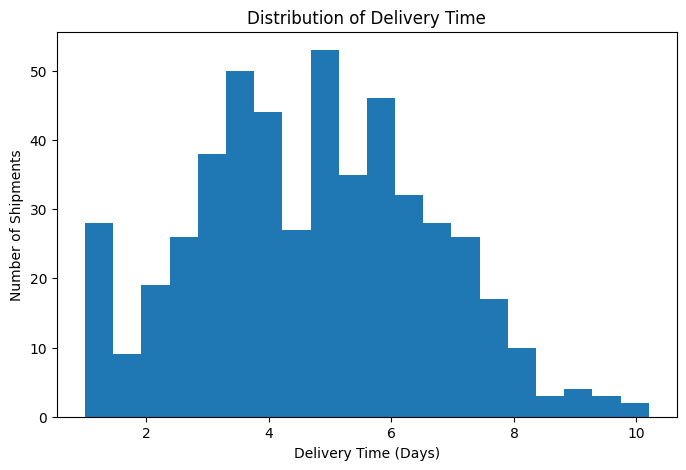

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    logistics_data["delivery_time_days"],
    bins=20
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

### **Interpretation**

The histogram shows how delivery times are distributed across the simulated shipments. Most shipments are concentrated within a relatively common delivery-time range, while fewer shipments require longer delivery durations. This helps logistics managers understand normal delivery patterns and identify shipments that may require further investigation.

## **5.4 Shipment Volume by Region**

A bar chart is used to compare shipment volume across geographic regions. Bar charts are effective for comparing values between discrete categories such as North, South, East, and West.

This visualization helps identify regions with higher shipment activity and can support decisions related to warehouse capacity, transportation resources, and workforce allocation.

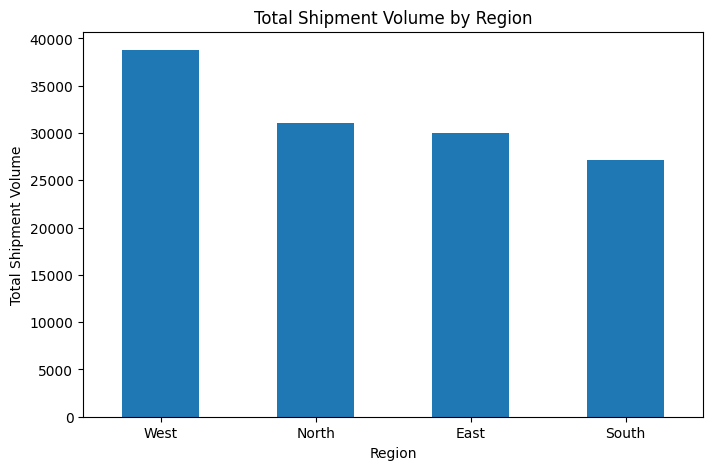

In [8]:
region_volume = (
    logistics_data
    .groupby("region")["shipment_volume"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_volume.plot(kind="bar")

plt.title("Total Shipment Volume by Region")
plt.xlabel("Region")
plt.ylabel("Total Shipment Volume")

plt.xticks(rotation=0)

plt.show()

### **Interpretation**

The bar chart compares total shipment volume across regions. Regions with higher shipment volumes may require greater transportation capacity, warehouse resources, and operational attention. This analysis can help logistics managers allocate resources according to regional demand.

## **5.5 Delivery Time by Transportation Mode**

A boxplot is used to compare delivery-time distributions across transportation modes. Boxplots show the median, spread, and potential extreme observations for each category.

This visualization helps identify differences in delivery performance between road, rail, air, and sea transportation.

<Figure size 800x500 with 0 Axes>

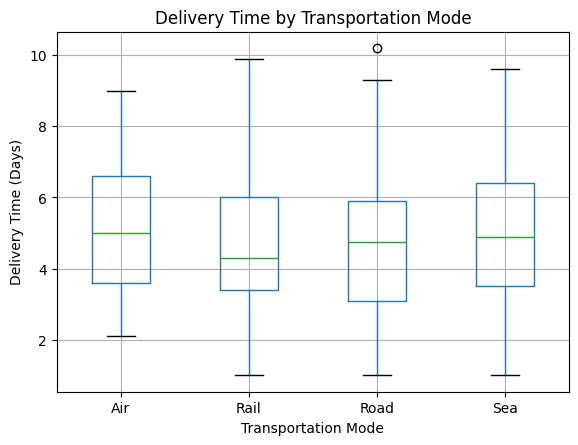

In [9]:
plt.figure(figsize=(8, 5))

logistics_data.boxplot(
    column="delivery_time_days",
    by="transport_mode"
)

plt.title("Delivery Time by Transportation Mode")
plt.suptitle("")
plt.xlabel("Transportation Mode")
plt.ylabel("Delivery Time (Days)")

plt.show()

### **Interpretation**

The boxplot allows comparison of delivery-time distributions across transportation modes. Differences in median delivery time and variability can indicate that some transportation modes are faster or more consistent than others. This information can support transportation-mode selection and logistics planning.

## **5.6 Distance vs Transportation Cost**

A scatter plot is used to examine the relationship between transportation distance and transportation cost. Scatter plots are suitable for identifying relationships between two numerical variables.

This analysis helps determine whether longer transportation distances are associated with higher logistics costs.

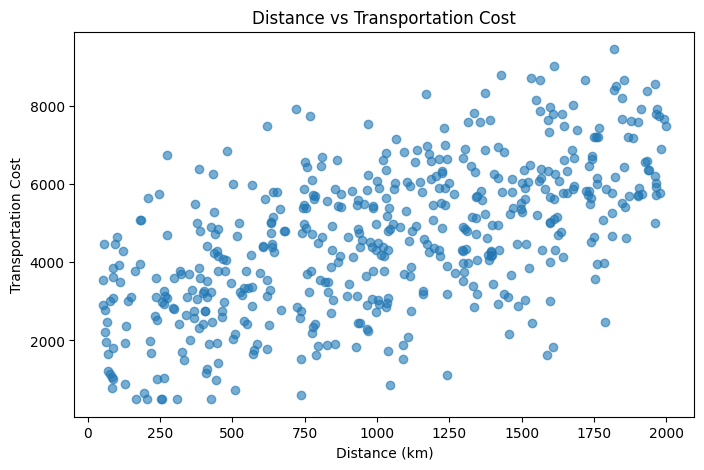

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    logistics_data["distance_km"],
    logistics_data["transportation_cost"],
    alpha=0.6
)

plt.title("Distance vs Transportation Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")

plt.show()

### **Interpretation**

The scatter plot shows the relationship between transportation distance and cost. The simulated data is designed so that transportation cost generally increases as distance increases. This indicates that distance can be an important cost driver in logistics operations.

## **5.7 Shipment Volume vs Transportation Cost**

A scatter plot is used to analyze the relationship between shipment volume and transportation cost. This helps determine whether larger shipment volumes are associated with increased transportation expenditure.

Understanding this relationship can support shipment consolidation and transportation planning decisions.

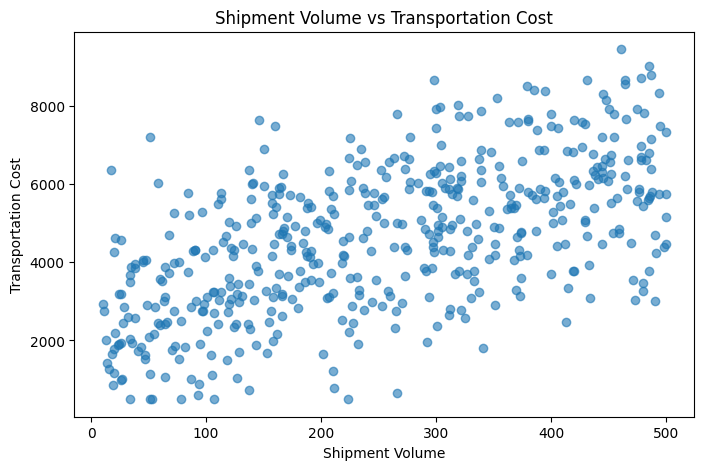

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    logistics_data["shipment_volume"],
    logistics_data["transportation_cost"],
    alpha=0.6
)

plt.title("Shipment Volume vs Transportation Cost")
plt.xlabel("Shipment Volume")
plt.ylabel("Transportation Cost")

plt.show()

### **Interpretation**

The scatter plot shows that transportation cost generally increases with shipment volume in the simulated dataset. Higher shipment volumes require greater transportation capacity, which can contribute to increased logistics expenditure. This relationship can help managers evaluate shipment consolidation and capacity planning strategies.

## **5.8 Monthly Shipment Trend**

A monthly shipment trend is created to examine changes in shipment activity over time. A line chart is appropriate for displaying trends across an ordered time period.

The month variable is simulated because the dataset is hypothetical.

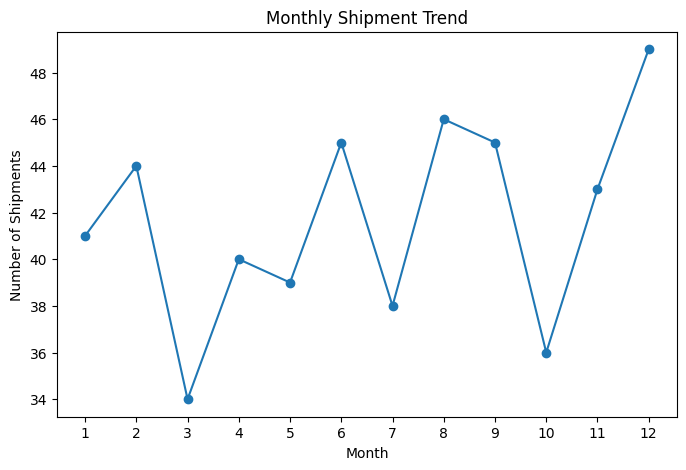

In [12]:
logistics_data["month"] = np.random.choice(
    range(1, 13),
    size=len(logistics_data)
)

monthly_shipments = (
    logistics_data
    .groupby("month")
    .size()
)

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_shipments.index,
    monthly_shipments.values,
    marker="o"
)

plt.title("Monthly Shipment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")

plt.xticks(range(1, 13))

plt.show()

### **Interpretation**

The line chart shows the number of simulated shipments across the twelve months. Changes in monthly shipment activity can help logistics planners identify periods of higher or lower demand and prepare transportation and operational resources accordingly.

## **5.9 Correlation Analysis**

Correlation analysis is used to measure the strength and direction of relationships between numerical logistics variables.

A correlation value ranges from -1 to +1:

- **+1** indicates a strong positive relationship.
- **0** indicates little or no linear relationship.
- **-1** indicates a strong negative relationship.

Correlation analysis can help identify important relationships between shipment volume, delivery time, transportation cost, and distance.

In [13]:
correlation_matrix = logistics_data[
    [
        "shipment_volume",
        "delivery_time_days",
        "transportation_cost",
        "distance_km"
    ]
].corr()

display(correlation_matrix)

,shipment_volume,delivery_time_days,transportation_cost,distance_km
shipment_volume,1.000000,-0.015985,0.597572,0.004537
delivery_time_days,-0.015985,1.000000,0.368114,0.654403
transportation_cost,0.597572,0.368114,1.000000,0.602485
distance_km,0.004537,0.654403,0.602485,1.000000


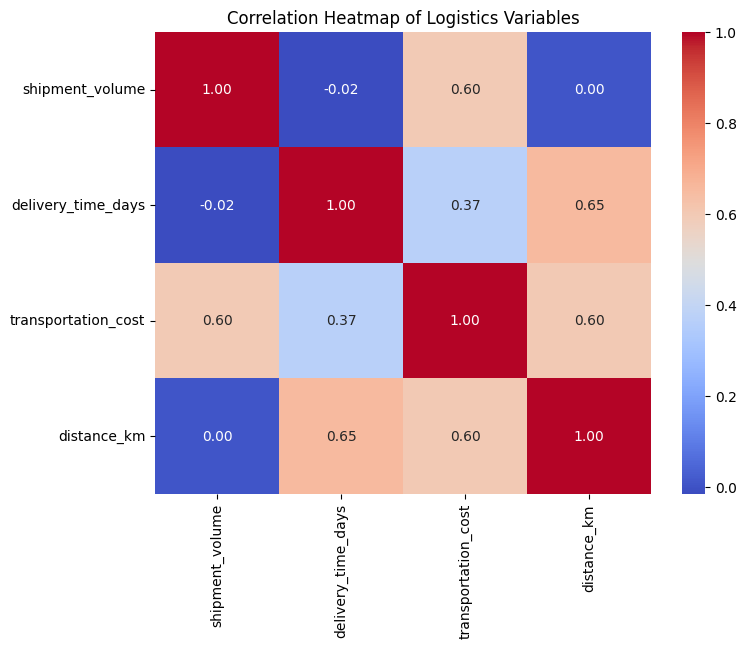

In [14]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Logistics Variables")

plt.show()

### **Interpretation**

The correlation heatmap provides a visual summary of relationships between the numerical logistics variables. Transportation cost is expected to show positive relationships with distance and shipment volume because longer distances and larger shipment volumes generally require greater transportation resources. The strength of these relationships can help identify potential cost drivers for logistics operations.

# **6. Logistics Performance Analysis**

The exploratory analysis is used to evaluate important logistics performance factors, including delivery time, shipment volume, transportation cost, transportation distance, and on-time delivery performance. These measures help identify operational patterns and support data-driven logistics decisions.

## **6.1 Delivery Time Analysis**

Delivery time is an important logistics performance metric because shorter and more consistent delivery times generally indicate better operational efficiency. The mean and median delivery times are calculated to understand the typical delivery performance of the simulated shipments.

In [15]:
average_delivery_time = logistics_data["delivery_time_days"].mean()
median_delivery_time = logistics_data["delivery_time_days"].median()

print("Average Delivery Time:", round(average_delivery_time, 2), "days")
print("Median Delivery Time:", round(median_delivery_time, 2), "days")

Average Delivery Time: 4.72 days
Median Delivery Time: 4.7 days


## **6.2 On-Time Delivery Analysis**

On-time delivery is an important logistics KPI that measures whether shipments are delivered within the expected delivery period. A higher on-time delivery rate generally indicates better delivery reliability.

The simulated dataset classifies shipments with a delivery time of seven days or less as on-time.

In [16]:
on_time_counts = logistics_data["on_time"].value_counts()

on_time_rate = logistics_data["on_time"].mean() * 100
late_rate = 100 - on_time_rate

print("On-Time Delivery Rate:", round(on_time_rate, 2), "%")
print("Late Delivery Rate:", round(late_rate, 2), "%")

print("\nOn-Time Delivery Counts:")
print(on_time_counts)

On-Time Delivery Rate: 88.4 %
Late Delivery Rate: 11.6 %

On-Time Delivery Counts:
on_time
True     442
False     58
Name: count, dtype: int64


## **6.3 Transportation Cost Analysis**

Transportation cost is an important logistics performance measure because it directly affects operational expenditure. Analyzing average transportation cost and comparing costs across transportation modes can help identify potential cost drivers and opportunities for optimization.

In [17]:
average_cost = logistics_data["transportation_cost"].mean()

print(
    "Average Transportation Cost:",
    round(average_cost, 2)
)

cost_by_mode = (
    logistics_data
    .groupby("transport_mode")["transportation_cost"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Transportation Cost by Mode:")
display(cost_by_mode)

Average Transportation Cost: 4621.88

Average Transportation Cost by Mode:


,transportation_cost
transport_mode,
Air,4849.402174
Sea,4604.547564
Road,4593.454018
Rail,4560.017674


## **6.4 Shipment Volume Analysis**

Shipment volume represents the amount of goods handled by the logistics operation. Understanding shipment volume by region and transportation mode can support capacity planning, resource allocation, and transportation scheduling.

In [18]:
volume_by_region = (
    logistics_data
    .groupby("region")["shipment_volume"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Shipment Volume by Region:")
display(volume_by_region)

volume_by_mode = (
    logistics_data
    .groupby("transport_mode")["shipment_volume"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal Shipment Volume by Transportation Mode:")
display(volume_by_mode)

Total Shipment Volume by Region:


,shipment_volume
region,
West,38767
North,31086
East,30014
South,27178



Total Shipment Volume by Transportation Mode:


,shipment_volume
transport_mode,
Road,56060
Rail,31906
Sea,20006
Air,19073


# **7. Analytical Insights**

The exploratory analysis and visualizations provide several useful insights into the simulated logistics operation.

### **1. Delivery Performance**

The delivery-time analysis provides an understanding of the typical time required to complete shipments. Comparing the mean and median helps identify the central delivery pattern and whether delivery times are influenced by unusually high values.

### **2. Transportation Cost**

The analysis indicates that transportation cost is influenced by important operational factors such as transportation distance and shipment volume. Longer distances generally require greater transportation resources, while larger shipment volumes may increase the required transportation capacity.

### **3. Regional Shipment Activity**

The regional shipment analysis shows differences in shipment volumes between geographic regions. Regions with higher shipment volumes may require greater warehouse capacity, transportation resources, and workforce allocation.

### **4. Transportation Mode**

The boxplot comparison demonstrates differences in delivery-time distributions between transportation modes. Some transportation modes may provide faster or more consistent delivery performance, while others may be more suitable for high-volume or long-distance transportation.

### **5. Relationship Between Distance and Cost**

The scatter plot demonstrates a positive relationship between transportation distance and transportation cost in the simulated dataset. This suggests that distance is an important potential cost driver.

### **6. Relationship Between Shipment Volume and Cost**

The analysis also indicates a relationship between shipment volume and transportation cost. Larger shipment volumes can require greater transportation capacity and therefore contribute to higher transportation expenditure.

### **7. Shipment Trends**

The monthly shipment visualization demonstrates variations in shipment activity across different months. Such variations can help logistics planners prepare resources for periods of relatively higher or lower demand.

# **8. Logistics Bottlenecks and Cost Drivers**

Based on the exploratory analysis, several potential logistics bottlenecks and cost drivers can be identified.

### **Potential Bottlenecks**

- Longer delivery times may indicate operational inefficiencies.
- High shipment volumes in particular regions may place additional pressure on logistics resources.
- Differences in transportation-mode performance may affect delivery consistency.
- Periods with higher shipment activity may require additional transportation and warehouse capacity.

### **Potential Cost Drivers**

- Transportation distance
- Shipment volume
- Transportation mode
- Required transportation capacity
- Variation in shipment demand

The identified factors should be investigated further using real operational data before making final business decisions.

# **9. Business Recommendations**

Based on the findings from the exploratory analysis, the following recommendations can support logistics efficiency:

### **1. Optimize Transportation Planning**

Transportation routes and modes should be selected based on distance, shipment volume, delivery requirements, and cost.

### **2. Improve Capacity Planning**

Regions with consistently high shipment volumes should receive appropriate transportation and warehouse capacity to prevent operational bottlenecks.

### **3. Monitor Delivery Performance**

Delivery-time KPIs should be monitored regularly to identify increasing delays and operational inefficiencies.

### **4. Control Transportation Costs**

Since distance and shipment volume can influence transportation costs, logistics managers should investigate route optimization and shipment consolidation opportunities.

### **5. Use Demand Trends for Resource Planning**

Monthly shipment patterns can be used to anticipate periods of higher demand and allocate transportation and workforce resources accordingly.

### **6. Apply Predictive Analytics in Future Work**

Future analysis can use machine-learning models to predict delivery delays, transportation costs, and high-risk shipments using historical logistics data.

# **10. Key Findings Summary**

The Week 3 analysis produced the following key findings:

- Delivery-time analysis provides an overview of logistics efficiency and delivery consistency.
- On-time delivery performance can be used as an important logistics KPI.
- Shipment volume varies across regions and transportation modes.
- Transportation distance is an important potential driver of transportation cost.
- Shipment volume can also contribute to higher transportation expenditure.
- Transportation modes may differ in their delivery-time performance.
- Monthly shipment trends can support demand and resource planning.
- Correlation analysis helps identify relationships between important numerical logistics variables.
- Data visualization makes complex logistics relationships easier to interpret and communicate.

# **11. Conclusion**

This Week 3 project demonstrated how advanced exploratory data analysis and visualization can be applied to logistics operations using Python. A hypothetical logistics dataset containing 500 shipment records was created to simulate realistic logistics activities involving shipment volume, delivery time, transportation cost, distance, region, transportation mode, and on-time delivery performance.

The analysis included descriptive statistics, central tendency measures, distribution analysis, correlation analysis, and multiple visualization techniques. Histograms were used to examine delivery-time distributions, bar charts were used to compare shipment volumes, boxplots were used to compare transportation modes, scatter plots were used to investigate relationships between numerical variables, line charts were used to examine shipment trends, and a correlation heatmap was used to summarize relationships among logistics variables.

The analysis demonstrated that logistics visualization can help identify delivery patterns, potential bottlenecks, and important cost drivers. Transportation distance and shipment volume were identified as important factors associated with transportation costs in the simulated dataset.

Overall, this project demonstrates the importance of combining exploratory data analysis with effective visualization to support data-driven logistics decision-making. Future work can extend this analysis using real operational data, predictive modeling, customer or shipment segmentation, and logistics optimization techniques.